# LIBERO CSV解析ノートブック（20Hz・5steps・default）

このノートブックでは、次のフォルダ配下にある `task_log.csv` と `episode_log.csv` をまとめて読み込み、
成功率・ステップ数・レイテンシを横断的に集計します。

`/work/csv/libero/20Hz-5steps (default)`

## 使い方

1. 上から順番にセルを実行してください。
2. `BASE_DIR` を変更すれば別ディレクトリにも使えます。
3. 最後のセルで集計結果CSVをエクスポートできます。

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

In [13]:
BASE_DIR = Path('/work/csv/libero/20Hz-5steps (default)')
CONTROL_FREQ_HZ = 20
REPLAN_STEPS = 5

task_log_paths = sorted(BASE_DIR.glob('**/task_log.csv'))
episode_log_paths = sorted(BASE_DIR.glob('**/episode_log.csv'))

print(f'対象ディレクトリ: {BASE_DIR}')
print(f'task_log.csv 件数: {len(task_log_paths)}')
print(f'episode_log.csv 件数: {len(episode_log_paths)}')

task_log_paths[:5], episode_log_paths[:5]

対象ディレクトリ: /work/csv/libero/20Hz-5steps (default)
task_log.csv 件数: 5
episode_log.csv 件数: 5


([PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_10/2026-04-20_13-29-03/task_log.csv'),
  PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_90/2026-04-20_15-03-56/task_log.csv'),
  PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_goal/2026-4-20/task_log.csv'),
  PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_object/2026-4-20/task_log.csv'),
  PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_spatial/2026-04-20_10-28-37/task_log.csv')],
 [PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_10/2026-04-20_13-29-03/episode_log.csv'),
  PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_90/2026-04-20_15-03-56/episode_log.csv'),
  PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_goal/2026-4-20/episode_log.csv'),
  PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_object/2026-4-20/episode_log.csv'),
  PosixPath('/work/csv/libero/20Hz-5steps (default)/libero_spatial/2026-04-20_10-28-37/episode_log.csv')])

In [14]:
def path_meta(csv_path: Path, base_dir: Path) -> dict:
    rel = csv_path.relative_to(base_dir)
    parts = rel.parts

    # 想定パス: <suite>/<run_id>/<file>
    suite = parts[0] if len(parts) >= 1 else 'unknown'
    run_id = parts[1] if len(parts) >= 2 else 'unknown'

    return {
        'suite': suite,
        'run_id': run_id,
        'source_file': str(csv_path),
    }

def load_many(csv_paths, base_dir: Path):
    frames = []
    for p in csv_paths:
        try:
            df = pd.read_csv(p)
            meta = path_meta(p, base_dir)
            for k, v in meta.items():
                df[k] = v
            frames.append(df)
        except Exception as e:
            print(f'[警告] 読み込みに失敗: {p}: {e}')

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

In [15]:
task_df = load_many(task_log_paths, BASE_DIR)
episode_df = load_many(episode_log_paths, BASE_DIR)

print('task_df shape:', task_df.shape)
print('episode_df shape:', episode_df.shape)

task_df.head(3)

task_df shape: (130, 10)
episode_df shape: (6500, 8)


,task_id,task_description,success_rate,steps_mean,steps_std,latency_mean_ms,latency_std_ms,suite,run_id,source_file
0,0,put both the alphabet soup and the tomato sauc...,0.96,301.42,61.795175,83.954926,3.589817,libero_10,2026-04-20_13-29-03,/work/csv/libero/20Hz-5steps (default)/libero_...
1,1,put both the cream cheese box and the butter i...,1.00,264.50,16.956710,83.174681,3.846785,libero_10,2026-04-20_13-29-03,/work/csv/libero/20Hz-5steps (default)/libero_...
2,2,turn on the stove and put the moka pot on it,0.98,266.32,47.672818,85.155392,3.715841,libero_10,2026-04-20_13-29-03,/work/csv/libero/20Hz-5steps (default)/libero_...


In [16]:
if not episode_df.empty and 'success' in episode_df.columns:
    # success列を 0/1 の数値へ正規化
    episode_df['success'] = episode_df['success'].astype(str).str.lower().map({
        'true': 1, 'false': 0, '1': 1, '0': 0
    }).fillna(0).astype(int)

if not episode_df.empty and 'steps' in episode_df.columns:
    episode_df['steps'] = pd.to_numeric(episode_df['steps'], errors='coerce')

if not episode_df.empty and 'avg_latency_ms' in episode_df.columns:
    episode_df['avg_latency_ms'] = pd.to_numeric(episode_df['avg_latency_ms'], errors='coerce')

if not task_df.empty:
    for col in ['success_rate', 'steps_mean', 'steps_std', 'latency_mean_ms', 'latency_std_ms']:
        if col in task_df.columns:
            task_df[col] = pd.to_numeric(task_df[col], errors='coerce')

In [17]:
# エピソード単位ログから全体統計を作成
global_summary = {}

if not episode_df.empty:
    global_summary = {
        'episodes': int(len(episode_df)),
        'success_rate': float(episode_df['success'].mean()) if 'success' in episode_df else np.nan,
        'steps_mean': float(episode_df['steps'].mean()) if 'steps' in episode_df else np.nan,
        'steps_std': float(episode_df['steps'].std()) if 'steps' in episode_df else np.nan,
        'latency_mean_ms': float(episode_df['avg_latency_ms'].mean()) if 'avg_latency_ms' in episode_df else np.nan,
        'latency_std_ms': float(episode_df['avg_latency_ms'].std()) if 'avg_latency_ms' in episode_df else np.nan,
    }

summary_df = pd.DataFrame([global_summary])
summary_df

,episodes,success_rate,steps_mean,steps_std,latency_mean_ms,latency_std_ms
0,6500,0.492615,295.449385,129.077292,82.638629,7.945563


In [ ]:
# スイート別の集計（平均値のみ）
if not episode_df.empty:
    by_suite = (
        episode_df.groupby('suite', as_index=False)
        .agg(
            episodes=('episode_idx', 'count'),
            success_rate=('success', 'mean'),
            steps_mean=('steps', 'mean'),
            latency_mean_ms=('avg_latency_ms', 'mean'),
        )
        .sort_values('success_rate', ascending=False)
    )
else:
    by_suite = pd.DataFrame()

by_suite

,suite,episodes,success_rate,steps_mean,steps_std,latency_mean_ms,latency_std_ms
4,libero_spatial,500,0.986000,116.844000,24.508550,81.956208,27.570516
3,libero_object,500,0.980000,151.878000,28.788690,81.166500,2.306089
2,libero_goal,500,0.966000,126.880000,52.489350,81.124263,2.372039
0,libero_10,500,0.938000,282.702000,89.172691,83.522485,2.176358
1,libero_90,4500,0.281556,351.393111,102.853726,82.948080,2.102011


In [ ]:
# suite_summary のみ使うため、task単位集計はスキップ
by_task = pd.DataFrame()
print('task単位集計はスキップしました（suite_summaryのみ出力）。')

,suite,task_description,success_rate,steps_mean,latency_mean_ms
113,libero_spatial,pick up the black bowl on the wooden cabinet a...,1.0,131.76,81.309111
100,libero_object,pick up the milk and place it in the basket,1.0,141.82,80.633058
99,libero_object,pick up the ketchup and place it in the basket,1.0,155.20,80.996025
104,libero_spatial,pick up the black bowl between the plate and t...,1.0,92.40,96.700120
30,libero_90,pick up the butter and put it in the basket,1.0,266.92,81.232446
93,libero_goal,turn on the stove,1.0,85.68,80.276575
97,libero_object,pick up the chocolate pudding and place it in ...,1.0,169.24,81.491578
20,libero_90,pick up the alphabet soup and put it in the tray,1.0,136.72,83.285630
105,libero_spatial,pick up the black bowl from table center and p...,1.0,108.66,79.972804
107,libero_spatial,pick up the black bowl next to the cookie box ...,1.0,119.70,80.468018


In [20]:
# 制御周波数と再計画間隔の派生指標
step_time_ms = 1000.0 / CONTROL_FREQ_HZ
replan_interval_ms = REPLAN_STEPS * step_time_ms

derived = {
    'control_freq_hz': CONTROL_FREQ_HZ,
    'step_time_ms': step_time_ms,
    'replan_steps': REPLAN_STEPS,
    'replan_interval_ms': replan_interval_ms,
}

if global_summary:
    mean_latency = global_summary.get('latency_mean_ms', np.nan)
    derived['latency_over_replan_ratio'] = mean_latency / replan_interval_ms if pd.notna(mean_latency) else np.nan

pd.DataFrame([derived])

,control_freq_hz,step_time_ms,replan_steps,replan_interval_ms,latency_over_replan_ratio
0,20,50.0,5,250.0,0.330555


/tmp/ipykernel_3167553/2914566218.py:22: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3167553/2914566218.py:22: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3167553/2914566218.py:22: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3167553/2914566218.py:22: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3167553/2914566218.py:22: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3167553/2914566218.py:22: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3167553/2914566218.py:22: UserWarning: Glyph 12452 (\N{KATAKANA LETTE

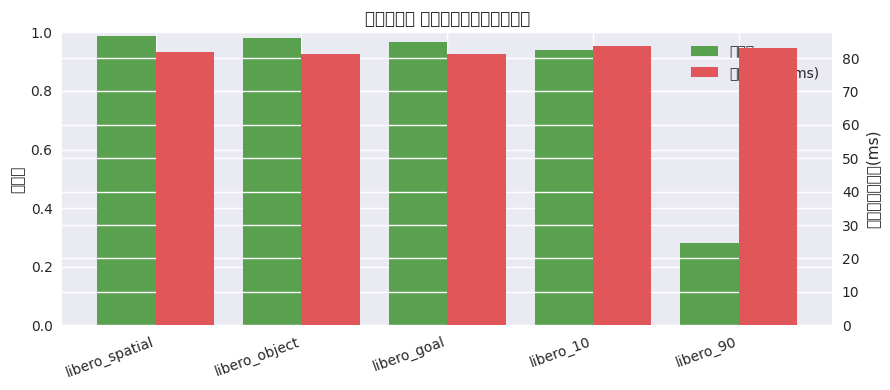

In [21]:
# 可視化2: スイート別 成功率と平均レイテンシ
if not by_suite.empty:
    fig, ax1 = plt.subplots(figsize=(9, 4))
    x = np.arange(len(by_suite))

    ax1.bar(x - 0.2, by_suite['success_rate'], width=0.4, label='成功率', color='#59A14F')
    ax1.set_ylabel('成功率')
    ax1.set_ylim(0, 1.0)

    ax2 = ax1.twinx()
    ax2.bar(x + 0.2, by_suite['latency_mean_ms'], width=0.4, label='平均レイテンシ(ms)', color='#E15759')
    ax2.set_ylabel('平均レイテンシ(ms)')

    ax1.set_xticks(x)
    ax1.set_xticklabels(by_suite['suite'], rotation=20, ha='right')
    ax1.set_title('スイート別 成功率と平均レイテンシ')

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper right')

    plt.tight_layout()
    plt.show()

In [ ]:
# suite_summary のみ使うため、上位/下位タスク表示はスキップ
print('上位/下位タスク表示はスキップしました（suite_summaryのみ）。')

成功率 上位10タスク


,suite,task_description,success_rate,steps_mean,latency_mean_ms
6,libero_10,put the white mug on the left plate and put th...,1.0,247.56,83.078683
112,libero_spatial,pick up the black bowl on the stove and place ...,1.0,136.74,80.386254
109,libero_spatial,pick up the black bowl next to the ramekin and...,1.0,120.22,80.705034
108,libero_spatial,pick up the black bowl next to the plate and p...,1.0,108.82,81.919942
107,libero_spatial,pick up the black bowl next to the cookie box ...,1.0,119.70,80.468018
105,libero_spatial,pick up the black bowl from table center and p...,1.0,108.66,79.972804
5,libero_10,put the black bowl in the bottom drawer of the...,1.0,235.18,86.519966
4,libero_10,put both the cream cheese box and the butter i...,1.0,264.50,83.174681
87,libero_goal,put the bowl on the plate,1.0,85.16,80.772611
71,libero_90,put the white mug on the left plate,1.0,111.92,81.327852


成功率 下位10タスク


,suite,task_description,success_rate,steps_mean,latency_mean_ms
17,libero_90,open the top drawer of the cabinet,0.0,410.0,83.195416
74,libero_90,put the wine bottle on the wine rack,0.0,410.0,83.447655
83,libero_90,turn on the stove and put the frying pan on it,0.0,410.0,83.081330
40,libero_90,pick up the salad dressing and put it in the tray,0.0,410.0,83.032621
37,libero_90,pick up the milk and put it in the basket,0.0,410.0,83.005254
39,libero_90,pick up the red mug and place it to the right ...,0.0,410.0,82.879683
36,libero_90,pick up the ketchup and put it in the tray,0.0,410.0,83.016428
79,libero_90,stack the middle black bowl on the back black ...,0.0,410.0,82.685990
29,libero_90,pick up the book on the right and place it und...,0.0,410.0,82.819611
59,libero_90,put the frying pan under the cabinet shelf,0.0,410.0,82.609035


In [ ]:
# suite_summary のみCSVで書き出し（平均値のみ）
out_dir = Path('/work/csv/libero/analysis_exports')
out_dir.mkdir(parents=True, exist_ok=True)

if not by_suite.empty:
    by_suite.to_csv(out_dir / 'suite_summary_20Hz_5steps_default.csv', index=False)
    print('suite_summary を書き出しました。')
    print(f'書き出し先: {out_dir / "suite_summary_20Hz_5steps_default.csv"}')
else:
    print('by_suite が空のため、書き出しをスキップしました。')

書き出し先: /work/csv/libero/analysis_exports
